In [1]:
import numpy as np
import random
import os
import torch

from torch.utils.data import DataLoader
from torchvision import transforms

## seeding for reproducibility in random events like dropout, Weight initialization, Data shuffling

def seed_all(seed =42):
    torch.manual_seed(seed) #seeding in CPU
    np.random.seed(seed) #seeding in np lib operations
    if torch.cuda.is_available(): # if the gpu is available
        torch.cuda.manual_seed_all(seed) # seed those operations

seed_all(42)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #initializing the device

print("using device:", device)

# configuration for architecture

n_qubits = 6
batch_size = 64 # higher as the size of image is very small
num_classes = 10
num_epochs = 80
lr = 0.0003

# small batchsize gives better generalization but a higher gives smooth gradient

using device: cuda


In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    #transforms.RandomHorizontalFlip(),  # check the effect of this, as its not recommended to use
    transforms.RandomRotation(10),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

test_transform = transforms.Compose([

    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
    
])

In [4]:
TRAIN_PATH = 'train'
TEST_PATH = 'test'

from torchvision.datasets import ImageFolder

try:
    # creates dataset object and label each classes
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    test_dataset = ImageFolder(TEST_PATH, transform=test_transform)

    print("dataset loaded successfully")

except Exception as e:
    print(f"Error loading datasets: {e}")

dataset loaded successfully


In [5]:
# giving each class weight as per it's size

try:
    labels = [label for _, label in train_dataset.samples]
    class_weights = compute_class_weight(class_weight = 'balanced', classes = np.unique(labels), y = labels) # array of class weights
    # converting to tensor for scikitlearn computation and giving it to the device used
    class_weight_tensor = torch.tensor(class_weight, dtype=torch.float).to(device) 
except:
    print("could not calculate class weights")
    print("Now using weights while training")
    class_weight_tensor = torch.ones(num_classes).to(device)

could not calculate class weights
Now using weights while training


In [6]:
from torch.utils.data import DataLoader

# after creating classes, shuffle dataset and group into batches
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers=4,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers=4, pin_memory=True)


In [7]:
import pennylane as qml

dev = qml.device("default.qubit",  wires = n_qubits) # device to run quantum cricuit

In [20]:
# to tasnform normal python function to qnode
    
# interface = torch - makes circuit compatible with PyTorch tensors and gradient will integrate with pytorch
# diff method - how gradients are calculated
# backfrop - uses classical automatic differentiator and only works with "default.qubit"

#weight(no_of samples, no_of_qubits=no_of_features)

@qml.qnode(dev, interface = "torch", diff_method = "backprop") # experiment with Parameter-shift also to validate its implication in real quantum device
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RX(inputs[..., i], wires=i)
        qml.RY(inputs[..., i], wires=i) #using two rotations for better expressivity
        
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i) 
            
        for i in range(n_qubits -1):
            qml.CNOT(wires= [i, i+1]) #giving CNOT is very important to make qubits dependent of each other
        qml.CNOT(wires=[n_qubits - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## alternatives: RX, RZ, RX+RZ gates, ring topology(tried in malimg), full connectivity --- experiment with this in datasets
weight_shapes = {"weights": (3, n_qubits)} 

In [21]:
import torch.nn as nn

# creatingn a custom neural network to reduce the dimension of the input(before this analyze input properly)

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.2): #subjected to changes based on the performace
        super().__init__()
        self.conv = nn.Sequential(
            #conv2d(input_channel, output_channel, kernel_size, stride, padding)
            nn.Conv2d(1, 16, 3, stride=1, padding=1),
            nn.BatchNorm2d(16), # for channelwise normalization
            nn.ReLU(), #default,  if most cells are giving output 0- use LeakyRELU()
            #nn.Dropout(dropout),# no need to use dropout, will use if required later

            nn.Conv2d(16, 32, 3, stride=2, padding=1), # if stride = 1 -> image will be average of 32 values in a single layer, cant focus on small patterns
            nn.BatchNorm2d(32),
            nn.ReLU(),
            #nn.Dropout(dropout), # during the mid layer, it wont help much
            
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.AdaptiveAvgPool2d((1,1))
            
        )
        #expand plus project strategy for better expessibility but adds risk of overfitting
        
        self.fc_expand = nn.Linear(64, n_qubits * 2) # was wrong, dataset is not very easy
        self.fc_project = nn.Linear(n_qubits * 2, n_qubits)
        self.activation = nn.ReLU()


    def forward(self, x):
        x = self.conv(x) # input must pass through all the layers defined earlier
        x= x.view(x.size(0), -1) 
        x = self.fc_expand(x)
        x = self.activation(x)
        x = self.fc_project(x)

        return x
        

In [22]:
class HybrideQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 32),  # projects data into 32 values
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, num_classes) 
        )

    def forward(self,x):
        x=self.feature_extractor(x)
        x=torch.tanh(x) # clips angle values to (-1,1)
        q_out=self.q_layer(x)
        return self.classifier(q_out)

In [23]:
from tqdm import tqdm

def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct = 0.0,0

    for inputs, labels in tqdm(dataloader, desc = "Training", leave = False):
        inputs, labels = inputs.to(device), labels.to(device) # giving input and its labels to the device for evaluation

        optimizer.zero_grad() # clears previous gradients(pytorch accumulate gradient of previous batch also)
        outputs = model(inputs) # gives prediction of the batch
        loss = loss_fn(outputs, labels) # finds loss by doing softmax(prob_of_correct_class)
        loss.backward() #computes gradients using backpropogation

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step() # weights are updated: (w_new = w_old - lr*gradient)

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item() # no of total correct predictions given by network
        
    return total_loss/len(dataloader), correct/len(dataloader.dataset) #gives: average loss per sample, average correct predicted samples


In [24]:
eval_transform = transforms.Compose([

    transforms.Grayscale(1),
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
    
])

Val_path = './val'

val_dataset = ImageFolder(Val_path, transform= eval_transform)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory=True)



In [25]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs =model(inputs)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1) #torch.max() gives (max_vlaue, index), so this will give intex of the maximum value(max probability class)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return total_loss/len(dataloader), correct/total

In [26]:
print("Initializing model...")

Initializing model...


In [29]:
from pennylane.qnn import TorchLayer

model = HybrideQNN(n_qubits= n_qubits, num_classes= num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.005)
loss_fn = loss_fn = nn.CrossEntropyLoss(weight=class_weight_tensor)
best_val_loss = float('inf')

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience =5)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

early_stopping_patience = 15

epochs_without_improvement = 0

print(f"Starting Training for {num_epochs} epochs with Two-Stage Loss Schedule...")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)

     
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "exp2.pth")
        print("   💾 Best model saved.")
    else:
        epochs_without_improvement += 1
        print(f"   🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"⏹️ Early stopping triggered after {epoch+1} epochs.")
        break

Starting Training for 80 epochs with Two-Stage Loss Schedule...


Epoch 1/80
   Train Loss: 1.9444 | Train Acc: 0.3673 | Val Acc: 0.4370
   💾 Best model saved.


Epoch 2/80
   Train Loss: 1.3070 | Train Acc: 0.5799 | Val Acc: 0.6210
   💾 Best model saved.


Epoch 3/80
   Train Loss: 1.0815 | Train Acc: 0.6112 | Val Acc: 0.6235
   💾 Best model saved.


Epoch 4/80
   Train Loss: 1.0151 | Train Acc: 0.6179 | Val Acc: 0.6266
   💾 Best model saved.


...

Epoch 70/80
   Train Loss: 0.4184 | Train Acc: 0.8769 | Val Acc: 0.8557
   🕒 No improvement for 4 epoch(s).


Epoch 71/80
   Train Loss: 0.4203 | Train Acc: 0.8764 | Val Acc: 0.8402
   🕒 No improvement for 5 epoch(s).


Epoch 72/80
   Train Loss: 0.4168 | Train Acc: 0.8747 | Val Acc: 0.8820
   🕒 No improvement for 6 epoch(s).


Epoch 73/80
   Train Loss: 0.4019 | Train Acc: 0.8765 | Val Acc: 0.8822
   🕒 No improvement for 7 epoch(s).


KeyboardInterrupt: 

In [30]:
'''
printing classifiction report to see where the model is lagging exactly

'''

import torch
from sklearn.metrics import classification_report
import numpy as np

model = HybrideQNN(n_qubits=n_qubits, num_classes=num_classes).to(device)
model.load_state_dict(torch.load("exp2.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:  # or val_loader
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, digits=4))



              precision    recall  f1-score   support

           0     0.3200    0.0457    0.0800       175
           1     0.9940    0.9980    0.9960       496
           2     0.8498    0.9659    0.9041       205
           3     0.9227    0.9489    0.9356       176
           4     1.0000    1.0000    1.0000        58
           5     0.9240    0.8794    0.9011       456
           6     0.9146    0.9721    0.9425      1003
           7     0.8100    0.9552    0.8766       491
           8     0.7368    0.7283    0.7326       173
           9     0.8263    0.7822    0.8037       225

    accuracy                         0.8887      3458
   macro avg     0.8298    0.8276    0.8172      3458
weighted avg     0.8656    0.8887    0.8705      3458



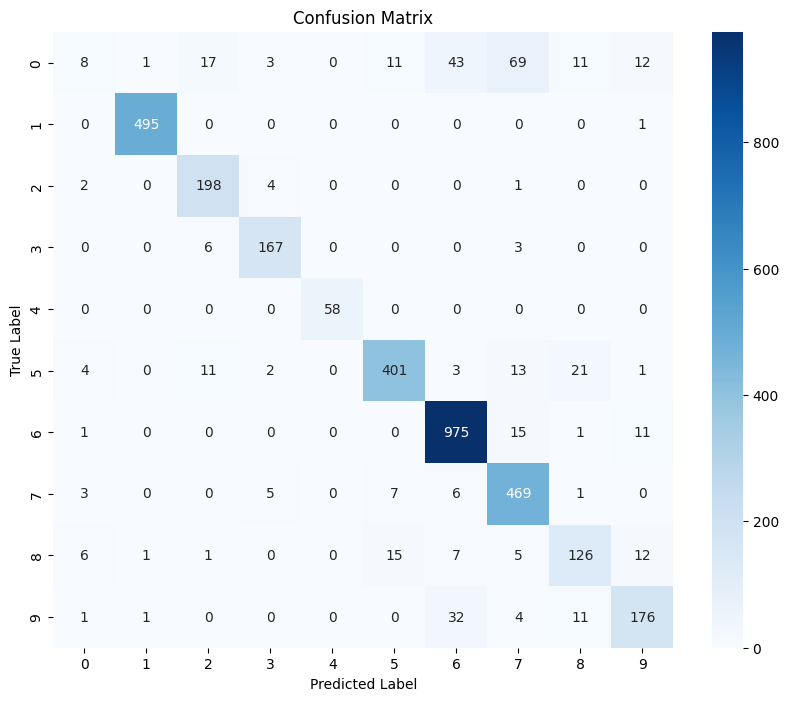

In [31]:
'''
printing confusion matrix to see if class 0 is similar to some other class or not
'''

import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:  # or val_loader
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


Feature shape: (3458, 6)


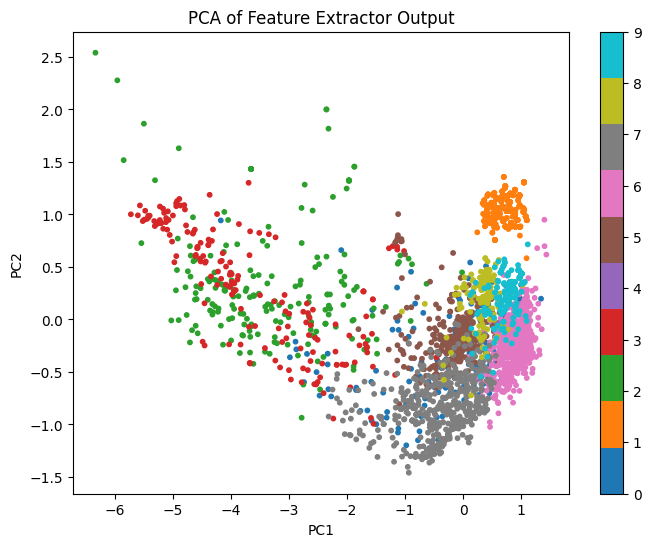

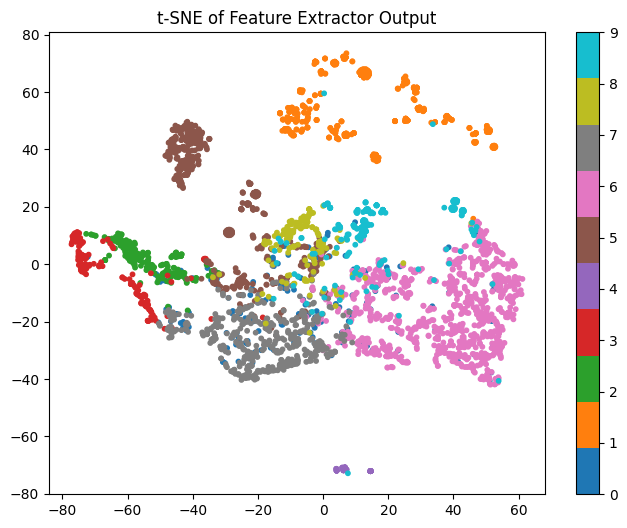

In [35]:
'''
plotting feature space: PCA and tsne
'''
import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load("exp2.pth"))
model.eval()


all_features = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        features = model.feature_extractor(inputs)  # shape: (batch_size, n_qubits)
        
        all_features.append(features.cpu())
        all_labels.append(labels)

all_features = torch.cat(all_features).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Feature shape:", all_features.shape)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1],
                      c=all_labels, cmap='tab10', s=10)

plt.colorbar(scatter)
plt.title("PCA of Feature Extractor Output")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(all_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(tsne_result[:,0], tsne_result[:,1],
                      c=all_labels, cmap='tab10', s=10)

plt.colorbar(scatter)
plt.title("t-SNE of Feature Extractor Output")
plt.show()

